In [1]:
import numpy as np
import sklearn as sk
from matplotlib import pyplot as plt #ignore
import requests

from sklearn.cluster import KMeans

In [2]:
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')

with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

print (names)

['GRB_name' 'GRB_name_Fermi' 'T0' 'ra' 'decl' 'pos_error' 'T90'
 'T90_error' 'T90_start' 'fluence' 'fluence_error' 'redshift' "'T100'"
 'GBM_located' 'mjd_(T0)']


/var/folders/qk/_k66m61n20l_yhkclqkkp8780000gn/T/ipykernel_84132/888736062.py:6: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')


In [3]:
t90  = data[6].astype(float)
flux = data[9].astype(float)

In [4]:
mask = (t90 > 0.0) & (flux > 0.0)
Flux = np.log(flux[mask])
T90 = np.log(t90[mask])

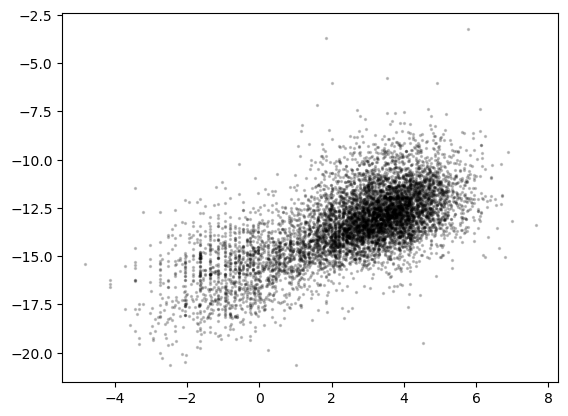

In [5]:
plt.scatter (T90, Flux, c='black', s=2, alpha=0.2)
plt.show()

# Clustering

## k-means clustering

In [6]:
X = np.array([T90, Flux]).T
clf = KMeans(n_clusters=2,n_init='auto')
clf.fit(X)
centers = clf.cluster_centers_
labels = clf.predict(X)
print (centers)

[[  3.5184499  -12.53066183]
 [  0.20636965 -15.42429974]]


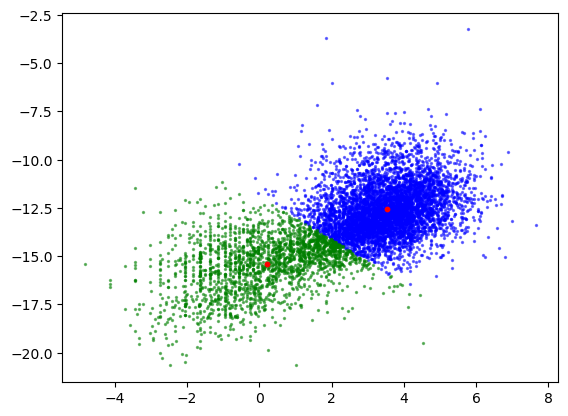

In [7]:
colors = ['blue', 'green']
for j in range (2):
    plt.scatter(X[labels==j, 0], X[labels==j, 1], c=colors[j], alpha = 0.5, s=2)
plt.scatter (centers[0,0], centers[0,1], s=10, c='red')
plt.scatter (centers[1,0], centers[1,1], s=10, c='red')
plt.show()